In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp




In [2]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimisers import *

import elements 
import importlib
importlib.reload(elements)



<module 'elements' from '/Users/matteogiacomelli/Documents/Fisica_Magistrale/SoftwareAndComputing/Technical-Student-2024-2025/Non-Resonant Extraction/elements.py'>

# CHecking if for a single pass TECA is recording the scattering

In [3]:
TECA = xc.EverestCrystal(
    length=2e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = - 174e-6 ,              # THIS CRYSTAL IS CHANNELING TOWARDS THE INSIDE OF THE RING!!!
    side="-",
    lattice="strip",
    #jaw = - 35e-3,  #Setting for simulation
    jaw = - 52e-3,  #original setting
    tilt = - 1.23e-3,
    width = 0.8e-3,
    height = 50e-3
    )


## Recording scatterings for multiple turns

In [4]:
line = initialise_lineQ22()

tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')


python(96562) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4603 [00:00<?, ?it/s]

Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21794_aper (index 1133) on turn 0
Adjusting ap.up.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21794_aper (index 1138) on turn 0
Adjusting ap.do.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle not lost during tracking.
The li

In [6]:
import optimisers as op
import importlib
importlib.reload(op)

# Set the initial conditions
optLSS4 = horizontal_bumpLSS4(line)

optLSS4.log()
optLSS4.solve()

# Set the initial conditions
optLSS2 = horizontal_bumpLSS2(line, x_target = 0.0394)

optLSS2.log()
optLSS2.solve()

# bump_closed_orbite = ensure_bump_closed(line)

# bump_closed_orbite.log()

# bump_closed_orbite.step(10)
# bump_closed_orbite.target_status()
# bump_closed_orbite.vary_status()
# knobs_after_closingOrbit = bump_closed_orbite.get_knob_values()
# knobs_after_closingOrbit = bump_closed_orbite.get_knob_values(iteration=0)

tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d")

                                             
Optimize - start penalty: 5.447e-15                         
Matching: model call n. 2 penalty = 5.4469e-15              
Optimize - end penalty:  5.44691e-15                            
                                             
Optimize - start penalty: 5.447e-15                         
Matching: model call n. 4 penalty = 5.4469e-15              
Optimize - end penalty:  5.44691e-15                            
                                             
Optimize - start penalty: 0.394                             
Matching: model call n. 22 penalty = 1.6595e-14              
Optimize - end penalty:  1.65946e-14                            
                                             
Optimize - start penalty: 1.659e-14                          
Matching: model call n. 24 penalty = 1.6595e-14              
Optimize - end penalty:  1.65946e-14                            


In [7]:
tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.2.*"].cols["k0l"]

bumpersLSS2 = list(line.vars.get_table().rows["kmp.h2.*[0-9]"].name)
bumpersLSS4 = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)

for bumper in bumpersLSS2:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

kmpsh21202 2.5552519200262305e-06
kmplh21431 0.0006534040125450621
kmpnh21732 0.00044544039139499645
kmplh21995 0.000651797829360266
kmplh22195 -0.00015103828439349385
kmpsh41402 -0.00030445747141598573
kmplh41658 -0.0004926350624711147
kmplh41994 -0.0004999496029717555
kmpsh42198 -9.860072490270115e-05


In [8]:
line.env["extr_bump_knob"] = 0.87 ## OPTIMAL FOR EXTRACTION
line.env["x_teca_knob"] = 1.048 ## OPTIMAL FOR EXTRACTION
#line.env["x_teca_knob"] = 1.02

In [9]:
for bumper in bumpersLSS2:
    line.vv[bumper] = bumper + "_init" + "*  extr_bump_knob"
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.vv[bumper] = bumper + "_init" + "*  x_teca_knob"
    print(bumper, line.vv[bumper])

kmpsh21202 2.2230691704228203e-06
kmplh21431 0.0005684614909142041
kmpnh21732 0.0003875331405136469
kmplh21995 0.0005670641115434314
kmplh22195 -0.00013140330742233964
kmpsh41402 -0.00031907143004395307
kmplh41658 -0.0005162815454697282
kmplh41994 -0.0005239471839143997
kmpsh42198 -0.00010333355969803081


In [10]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)
print(septa_names_with_apertures)

n_part = 500

x_norm   = np.random.normal(loc = 0, scale = 1, size=n_part)
px_norm =  np.random.normal(loc = 0, scale = 1, size=n_part)  # in between being channeled and not
#x_norm  = TECA.jaw * np.ones(n_part)
#px_norm = TECA.tilt * np.ones(n_part)
y_norm, py_norm = np.zeros(n_part), np.zeros(n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * deltaP_P

line.build_tracker()

N_EX = 10e-7 # REDUCED NORMALISED EMITTANCE BY A FACTOR 10 AS MASSIMO GIOVANNOZZI SUGGESTED, IT IMPOVES THE EFFICIENY BY 1% !!!

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
#tw_lss2 = tw.rows['TECA.entry':'_end_point']

tw_lss2 = tw.rows[:]


line.discard_tracker()

num_turns = 10000

# Define the momentum increment per turn (Δp₀c)
#delta_p0c =  2000e9 / 10 * 23e-6  # Example: 450 GeV over 10 s with 23 μs revolution time
delta_p0c = - 0.8e9 / num_turns  # THE SPS ENERGY CAN GO UP TO 400.6 GeV SO I ASSUME 0.6 GeV DIVIDED BY 100 TURNS

# Create the ReferenceEnergyIncrease element
energy_increase = xt.ReferenceEnergyIncrease(Delta_p0c=delta_p0c)

# Append the energy increase element to the end of the line
line.append_element(energy_increase, name='energy_increase')

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']


The line has collective elements.
In the twiss computation collective elements are replaced by drifts


<Line  at 4586027024>

In [11]:
#PLACING ONLY TWO MONITORS TO SAVE TIME
# Convert Twiss table to DataFrame and set 'name' as index
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

# Remove tracker before inserting new elements
line.discard_tracker()

monitor_tun_number = 100

# INSERT THE FOLLOWING MONITORS IF YOU WANT TO GET THE PHASE SPACE PLOTS AT THE END OF THE SIMULATION

# Insert monitor only at 'TECA.exit'
monitor_teca = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TECA_monitor', element=monitor_teca, index='TECA.exit')
tw_lss2_df.loc['TECA.exit', 'monitors'] = monitor_teca



# # Insert monitor only at 'tpst.21760_entry'
# monitor_tpst = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
# line.insert_element(name='TPST_monitor', element=monitor_tpst, index='tpst.21760_entry')
# tw_lss2_df.loc['tpst.21760_entry', 'monitors'] = monitor_tpst

# # Insert monitor only at tcsm.51932.
# monitor_tcsm = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
# line.insert_element(name='TCSM_monitor', element=monitor_tcsm, index='tcsm.51932.')
# tw_lss2_df.loc['tcsm.51932.', 'monitors'] = monitor_tcsm

line.discard_tracker()
#line.insert_element("extraction.crystal.TECS", TECS, at_s=line.get_table()['s', 'tecs.21602'] )



# Move the blade_position of 'mst.21794.sep'
element_name = 'mst.21794.sep'
line[element_name].interaction_process.blade_position += 0.002  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21794.sep: 0.04601 m


In [12]:
# Add before tracking
print("Crystal settings:")
print(f"TECA jaw position: {TECA.jaw}")
print(f"TECA tilt: {TECA.tilt}")
#print(f"TECA s-position: {line.get_s_position('extraction.crystal.TECA')}")

print("\nParticle distribution:")
print(f"x range: [{particles.x.min():.2e}, {particles.x.max():.2e}] m")
print(f"px range: [{particles.px.min():.2e}, {particles.px.max():.2e}] rad")

# After tracking, add this diagnostic
print("\nParticle states after tracking:")
print(f"Number of particles: {n_part}")
print(f"Number lost: {np.sum(particles.state < 1)}")
print(f"State values: {np.unique(particles.state)}")

Crystal settings:
TECA jaw position: -0.052
TECA tilt: -0.00123

Particle distribution:
x range: [-9.23e-04, 1.08e-02] m
px range: [-1.86e-05, 2.17e-04] rad

Particle states after tracking:
Number of particles: 500
Number lost: 0
State values: [1]


In [13]:
# line.discard_tracker()
# #line.build_tracker(_context=xo.ContextCpu())
# context = xo.ContextCpu()
# io_buffer = xt.new_io_buffer(capacity=int(1e7))

# TECA.record_scatterings = True

# line.insert_element("extraction.crystal.TECA", TECA, at_s = line.get_table()['s', 'TECA.entry'] )

# impacts = xt.start_internal_logging(elements=[TECA], io_buffer=io_buffer, capacity=io_buffer.capacity)

# line.build_tracker(_context=xo.ContextCpu())

# line.track(
#     particles,
#     num_turns=num_turns,
#     turn_by_turn_monitor=True,
#     # freeze_longitudinal=True,
#     time=True
# )
# if np.any(particles.state < 1):
#     lost_particles = np.where(particles.state < 1)[0]
#     print(f"Particles lost during tracking: {len(lost_particles)}")
# else:
#     print("No particles lost during tracking")
# record = line.time_last_track

# # Sort particles again
# particles.sort(interleave_lost_particles=True)

In [14]:
# First, completely clean up
line.discard_tracker()

# Create context and buffer with explicit settings
context = xo.ContextCpu()
io_buffer = xt.new_io_buffer(capacity=int(1e7))

# Remove TECA if it exists
if "extraction.crystal.TECA" in line.element_names:
    line.remove_element("extraction.crystal.TECA")

# Create a fresh TECA instance
TECA = xc.EverestCrystal(
    length=2e-3,
    material=xc.materials.SiliconCrystal,
    bending_angle=-174e-6,
    side="-",
    lattice="strip",
    jaw=-52e-3,
    tilt=-1.23e-3,
    width=0.8e-3,
    height=50e-3,
)

# Enable recording
TECA.record_scatterings = True

# Insert TECA into line
line.insert_element("extraction.crystal.TECA", TECA, at_s=line.get_table()['s', 'TECA.entry'])

# Verify TECA is in line
print("Verification after insertion:")
print(f"TECA in line: {'extraction.crystal.TECA' in line.element_names}")
print(f"TECA position: {line.get_s_position('extraction.crystal.TECA')}")

# Start logging with element name
impacts = xt.start_internal_logging(
    elements=[TECA],
    io_buffer=io_buffer,
    capacity=io_buffer.capacity
)
#impacts = xt.start_internal_logging(elements=[TECA], io_buffer=io_buffer, capacity=io_buffer.capacity)

# Build tracker
line.build_tracker(_context=context)

# Final verification
print("\nFinal setup verification:")
print(f"TECA recording enabled: {TECA.record_scatterings}")
# Note: impacts does not have an 'elements' attribute.
# If you want to check what was logged, inspect the logger setup or the impacts DataFrame after tracking.

# Track with explicit context
line.track(
    particles,
    num_turns=num_turns,
    turn_by_turn_monitor=True
)

# Check impacts immediately
df = impacts.to_pandas()
print(f"\nImpacts dataframe shape: {df.shape if not df.empty else 'Empty'}")

Slicing line:   0%|          | 0/4618 [00:00<?, ?it/s]

Verification after insertion:
TECA in line: True
TECA position: 4020.8939

Final setup verification:
TECA recording enabled: True

Impacts dataframe shape: Empty


In [15]:
# First check if we have any impacts data
if df.empty:
    print("No impacts were recorded!")
else:
    # Create figure with multiple subplots
    fig, ((ax3, ax4)) = plt.subplots(1, 2, figsize=(15, 12))
    
    # # Plot 1: X-Y positions of impacts
    # if 'x' in df.columns and 'y' in df.columns:
    #     ax1.scatter(df['x'], df['y'], alpha=0.5, s=20)
    #     ax1.set_xlabel('x [m]')
    #     ax1.set_ylabel('y [m]')
    #     ax1.set_title('Impact Positions (x-y)')
    #     ax1.grid(True)
    
    # # Plot 2: X-PX phase space
    # if 'x' in df.columns and 'px' in df.columns:
    #     ax2.scatter(df['x'], df['px'], alpha=0.5, s=20)
    #     ax2.set_xlabel('x [m]')
    #     ax2.set_ylabel('px [rad]')
    #     ax2.set_title('Phase Space (x-px)')
    #     ax2.grid(True)
    
    # Plot 3: Turn number distribution
    if 'turn' in df.columns:
        ax3.hist(df['turn'], bins=20, alpha=0.7)
        ax3.set_xlabel('Turn Number')
        ax3.set_ylabel('Count')
        ax3.set_xlim(df['turn'].min(), df['turn'].max())
        ax3.set_title('Distribution of Impacts per Turn')
        ax3.grid(True)
    
    # Plot 4: Interaction types if available
    if 'interaction_type' in df.columns:
        interaction_counts = df['interaction_type'].value_counts()
        ax4.bar(range(len(interaction_counts)), interaction_counts.values)
        ax4.set_xticks(range(len(interaction_counts)))
        ax4.set_xticklabels(interaction_counts.index, rotation=45)
        ax4.set_ylabel('Count')
        ax4.set_title('Interaction Types')
        ax4.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\nSummary Statistics:")
    if 'turn' in df.columns:
        print(f"Total number of impacts: {len(df)}")
        print(f"First impact at turn: {df['turn'].min()}")
        print(f"Last impact at turn: {df['turn'].max()}")
    
    if 'interaction_type' in df.columns:
        print("\nInteraction types distribution:")
        print(df['interaction_type'].value_counts())

No impacts were recorded!


In [16]:
df

,turn,collimator_id,interaction_type,id_before,s_before,x_before,px_before,y_before,py_before,zeta_before,...,y_after,py_after,zeta_after,delta_after,energy_after,mass_after,charge_after,z_after,a_after,pdgid_after


In [17]:
particles.to_pandas()

,y,at_turn,t_sim,chi,start_tracking_at_element,at_element,px,parent_particle_id,weight,_rng_s2,...,particle_id,mass0,state,delta,ptau,rvv,rpp,p0c,beta0,gamma0
0,2.578377e-23,10000,0.000023,1.0,-1,0,0.000264,80,1.0,3334438774,...,80,9.382721e+08,1,0.002026,0.002026,1.0,0.997978,3.998000e+11,0.999997,426.103586
1,2.488203e-23,10000,0.000023,1.0,-1,0,0.000272,81,1.0,75562128,...,81,9.382721e+08,1,0.002054,0.002054,1.0,0.997950,3.998000e+11,0.999997,426.103586
2,-3.603280e-23,9995,0.000023,1.0,-1,1130,0.000653,355,1.0,3449377095,...,355,9.382721e+08,-1,0.002020,0.002020,1.0,0.997984,3.998004e+11,0.999997,426.104012
3,-4.639103e-25,9980,0.000023,1.0,-1,1130,0.000654,349,1.0,2283575621,...,349,9.382721e+08,-1,0.002063,0.002063,1.0,0.997941,3.998016e+11,0.999997,426.105291
4,-2.203935e-23,9925,0.000023,1.0,-1,1130,0.000655,142,1.0,95312776,...,142,9.382721e+08,-1,0.002014,0.002014,1.0,0.997990,3.998060e+11,0.999997,426.109980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-3.185931e-23,773,0.000023,1.0,-1,1130,0.000657,375,1.0,484845803,...,375,9.382721e+08,-1,0.001544,0.001544,1.0,0.998458,4.005382e+11,0.999997,426.890306
496,3.591300e-23,749,0.000023,1.0,-1,1130,0.000659,268,1.0,2067348708,...,268,9.382721e+08,-1,0.001635,0.001635,1.0,0.998367,4.005401e+11,0.999997,426.892352
497,-3.532562e-23,708,0.000023,1.0,-1,1130,0.000656,397,1.0,3813301931,...,397,9.382721e+08,-1,0.001619,0.001619,1.0,0.998383,4.005434e+11,0.999997,426.895848
498,-2.658813e-23,403,0.000023,1.0,-1,1130,0.000659,66,1.0,2030759644,...,66,9.382721e+08,-1,0.001398,0.001398,1.0,0.998604,4.005678e+11,0.999997,426.921853


In [18]:
p = particles.to_pandas()[['particle_id', 'state', 'at_element']]
p.index = p.particle_id
p['lost_at'] = [line.element_names[particles.at_element[idx]] for idx in p.particle_id]
p

,particle_id,state,at_element,lost_at
particle_id,,,,
80,80,1,0,mst.21779.sep
81,81,1,0,mst.21779.sep
355,355,-1,1130,mst.21779.sep
349,349,-1,1130,mst.21779.sep
142,142,-1,1130,mst.21779.sep
...,...,...,...,...
375,375,-1,1130,mst.21779.sep
268,268,-1,1130,mst.21779.sep
397,397,-1,1130,mst.21779.sep


In [19]:
df

,turn,collimator_id,interaction_type,id_before,s_before,x_before,px_before,y_before,py_before,zeta_before,...,y_after,py_after,zeta_after,delta_after,energy_after,mass_after,charge_after,z_after,a_after,pdgid_after


In [20]:
df1 = df[['turn', 'interaction_type', 'id_before']].copy()
df1.index = df1['id_before']

In [21]:
df2 = df1.join(p, how='inner')
df2

,turn,interaction_type,id_before,particle_id,state,at_element,lost_at
id_before,,,,,,,


In [22]:
df2.plot?

Signature:      df2.plot(*args, **kwargs)
Type:           PlotAccessor
String form:    <pandas.plotting._core.PlotAccessor object at 0x115471490>
File:           ~/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/pandas/plotting/_core.py
Docstring:     
Make plots of Series or DataFrame.

Uses the backend specified by the
option ``plotting.backend``. By default, matplotlib is used.

Parameters
----------
data : Series or DataFrame
    The object for which the method is called.
x : label or position, default None
    Only used if data is a DataFrame.
y : label, position or list of label, positions, default None
    Allows plotting of one column versus another. Only used if data is a
    DataFrame.
kind : str
    The kind of plot to produce:

    - 'line' : line plot (default)
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hist' : histogram
    - 'box' : boxplot
    - 'kde' : Kernel Density Estimation plot
    - 'density' : same as 'kde'
    - 'area' : a

In [23]:
extr = df2[df2.state == 0].groupby(['turn']).particle_id.count()
lost = df2[df2.state == -1].groupby(['turn']).particle_id.count()

In [24]:
d =dict(
    extracted = [],
    lost = [],
)
for i in range(num_turns):
    try:
        extracted = extr.loc[i]
    except:
        extracted = 0
    
    try:
        lost = lost.loc[i]
    except:
        lost = 0
    d['extracted'].append(extracted)
    d['lost'].append(lost)
    
df3 = pd.DataFrame(d, index=range(num_turns))
df3

,extracted,lost
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
9995,0,0
9996,0,0
9997,0,0
9998,0,0


In [25]:
# Calculate efficiency: particles lost at 'tt20.extraction' over total number of lost particles

# Get indices of lost particles
lost_particles = np.where(particles.state < 1)[0]

# Find indices of lost particles at 'tt20.extraction'
lost_at_tt20 = [
    idx for idx in lost_particles
    if line.element_names[particles.at_element[idx]] == 'tt20.extraction'
]

n_lost_tt20 = len(lost_at_tt20)
n_lost_total = len(lost_particles)

if n_lost_total > 0:
    efficiency = n_lost_tt20 / n_lost_total
    print(f"Efficiency (lost at tt20 / total lost): {efficiency:.4%} ({n_lost_tt20}/{n_lost_total})")
else:
    efficiency = 0.0
    print("No particles were lost during tracking.")

Efficiency (lost at tt20 / total lost): 0.0000% (0/498)


In [29]:
# Add before tracking
print("Tracking setup verification:")
print(f"TECA recording enabled: {TECA.record_scatterings}")
print(f"IO buffer capacity: {io_buffer.capacity}")

# Check if TECA is in the logged elements (use .elements, not ._elements)
teca_in_logged = any(
	getattr(el, "name", None) == "extraction.crystal.TECA"
	for el in getattr(impacts, "elements", [])
)
print(f"TECA in logged elements: {teca_in_logged}")

Tracking setup verification:
TECA recording enabled: True
IO buffer capacity: 2490000816
TECA in logged elements: False


In [31]:
import numpy as np

# Get indices of lost particles
lost_particles = np.where(particles.state < 1)[0]

if len(lost_particles) > 0:
    print(f"Number of lost particles: {len(lost_particles)}")
    print("\nParticle loss locations:")

    # Get element names from the line
    element_names = line.element_names

    # Count losses per element
    loss_counts = {}
    for idx in lost_particles:
        lost_at = particles.at_element[idx]  # Index of element where the particle was lost
        lost_element_name = element_names[lost_at]
        loss_counts[lost_element_name] = loss_counts.get(lost_element_name, 0) + 1

    # Print where the particles were lost
    for element, count in loss_counts.items():
        print(f"{count} particles lost at element '{element}'")
else:
    print("No particles were lost during tracking")
    
# Calculate extraction efficiency: particles lost at 'tt20' / total number of particles

# Find indices of lost particles at 'tt20'
lost_at_tt20 = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tt20.extraction'
]

n_lost_tt20 = len(lost_at_tt20)
n_total = particles_init._capacity

if n_total > 0:
    efficiency = n_lost_tt20 / n_total
    print(f"Extraction efficiency at 'tt20': {efficiency:.4%} ({n_lost_tt20}/{n_total})")
else:
    print("No particles in the initial distribution.")

Number of lost particles: 498

Particle loss locations:
498 particles lost at element 'mst.21779.sep'
Extraction efficiency at 'tt20': 0.0000% (0/500)


In [32]:
# Get indices of lost particles
lost_particles = np.where(particles.state < 1)[0]

if len(lost_particles) > 0:
    print(f"Total number of lost particles: {len(lost_particles)}")
    print("\nLost particle details:")
    for idx in lost_particles:
        element_name = line.element_names[particles.at_element[idx]]
        turn_number = particles.at_turn[idx]
        print(f"Particle {idx}: lost at turn {turn_number} in element '{element_name}'")
    
    # Calculate statistics
    turn_stats = np.array([particles.at_turn[idx] for idx in lost_particles])
    print(f"\nTurn loss statistics:")
    print(f"Mean turn of loss: {np.mean(turn_stats):.1f}")
    print(f"Min turn of loss: {np.min(turn_stats)}")
    print(f"Max turn of loss: {np.max(turn_stats)}")
else:
    print("No particles were lost during tracking")

Total number of lost particles: 498

Lost particle details:
Particle 2: lost at turn 9995 in element 'mst.21779.sep'
Particle 3: lost at turn 9980 in element 'mst.21779.sep'
Particle 4: lost at turn 9925 in element 'mst.21779.sep'
Particle 5: lost at turn 9878 in element 'mst.21779.sep'
Particle 6: lost at turn 9811 in element 'mst.21779.sep'
Particle 7: lost at turn 9779 in element 'mst.21779.sep'
Particle 8: lost at turn 9778 in element 'mst.21779.sep'
Particle 9: lost at turn 9778 in element 'mst.21779.sep'
Particle 10: lost at turn 9775 in element 'mst.21779.sep'
Particle 11: lost at turn 9758 in element 'mst.21779.sep'
Particle 12: lost at turn 9613 in element 'mst.21779.sep'
Particle 13: lost at turn 9545 in element 'mst.21779.sep'
Particle 14: lost at turn 9545 in element 'mst.21779.sep'
Particle 15: lost at turn 9526 in element 'mst.21779.sep'
Particle 16: lost at turn 9507 in element 'mst.21779.sep'
Particle 17: lost at turn 9493 in element 'mst.21779.sep'
Particle 18: lost at

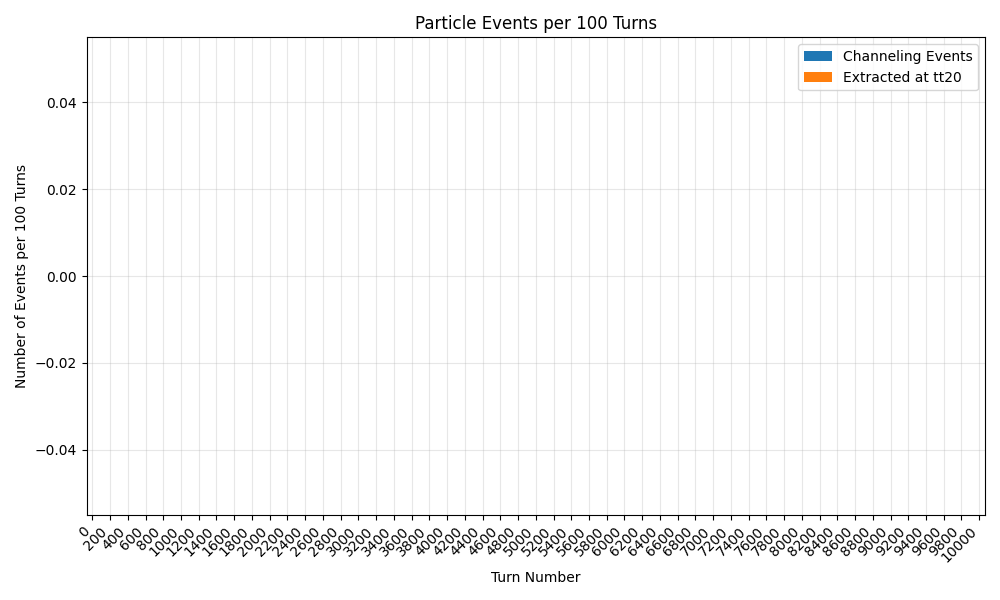

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create bins of 100 turns
bin_size = 100
n_bins = num_turns // bin_size + 1  # Add 1 to include any remaining turns
bins = np.arange(0, (n_bins + 1) * bin_size, bin_size)

# Aggregate data for channeling events
channeling_df = df[df['interaction_type'] == "Channeling"]
channeling_data = np.zeros(n_bins)
for i in channeling_df['turn']:
    bin_index = i // bin_size
    if bin_index < n_bins:  # Ensure we don't exceed array bounds
        channeling_data[bin_index] += 1

# Aggregate data for lost particles
lost_particles = np.where(particles.state < 1)[0]
lost_data = np.zeros(n_bins)
for idx in lost_particles:
    turn = particles.at_turn[idx]
    bin_index = turn // bin_size
    if bin_index < n_bins:  # Ensure we don't exceed array bounds
        lost_data[bin_index] += 1

# Aggregate data for particles lost at tt20.extraction
lost_at_tt20 = [idx for idx in lost_particles if line.element_names[particles.at_element[idx]] == 'tt20.extraction']
tt20_data = np.zeros(n_bins)
for idx in lost_at_tt20:
    turn = particles.at_turn[idx]
    bin_index = turn // bin_size
    if bin_index < n_bins:  # Ensure we don't exceed array bounds
        tt20_data[bin_index] += 1


# Create DataFrame with the binned data
df_binned = pd.DataFrame({
    'channeling': channeling_data,
    #'lost': lost_data,
    'extracted': tt20_data
}, index=bins[:-1])

# Plot
df_binned.plot(kind='bar', ax=ax, width=0.8)

plt.xlabel('Turn Number')
plt.ylabel('Number of Events per 100 Turns')
plt.title('Particle Events per 100 Turns')
plt.legend(['Channeling Events', 'Extracted at tt20'])
plt.grid(True, alpha=0.3)

# Show every Nth label for better readability
N = 2  # Adjust this value to show more or fewer labels
plt.xticks(range(0, len(bins)-1, N), bins[:-1:N], rotation=45, ha='right')

plt.tight_layout()